# Random Variance in Mutation

In [1]:
# dictionaries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import truncnorm, lognorm, gamma

/Users/elisaheinrichmora/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Haploid

#### One Allele Modifier

In [150]:
def simulate_haploid_selection_mutation(x1, u1, v1, s, generations):
    """
    Simulates haploid population dynamics under selection and mutation.

    Args:
        x1 (float): Initial frequency of AM1 (allele A).
        u1 (float): Mutation rate from A to a.
        v1 (float): Mutation rate from a to A.
        s (float): Selection coefficient against a.
        generations (int): Number of generations to simulate.

    Returns:
        list of float: History of x1 (frequency of AM1) over generations.
    """
    # Initialize history with full precision
    history = [float(x1)]

    for _ in range(generations):
        # Calculate x2 as 1 - x1 with full precision
        x2 = 1.0 - x1

        # Compute fitnesses with full precision
        W_A = 1.0
        W_a = 1.0 - float(s)
        
        W_bar = W_A * x1 + W_a * x2

        # Selection step
        x1_prime = float(x1) * W_A / W_bar
        x2_prime = float(x2) * W_a / W_bar

        # Mutation step with full precision
        x1_next = float(x1_prime) * (1.0 - float(u1)) + float(x2_prime) * float(v1)
        x2_next = float(x2_prime) * (1.0 - float(v1)) + float(x1_prime) * float(u1)

        # Normalize frequencies to ensure they sum to 1
        total = x1_next + x2_next
        x1_next /= total
        x2_next /= total

        # Update for next generation
        x1 = float(x1_next)
        history.append(x1)
        
    return history

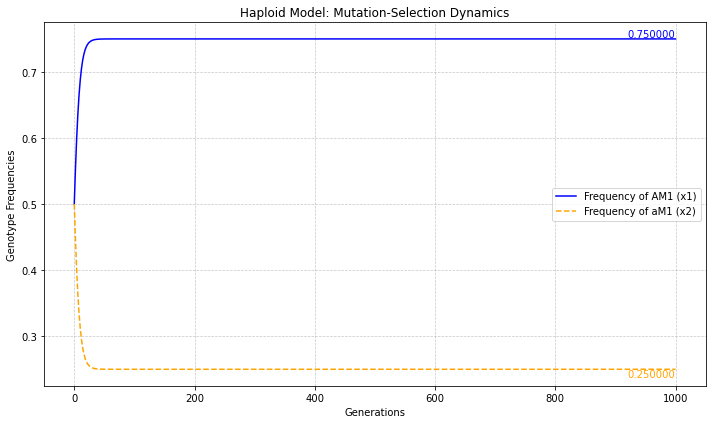

In [151]:
# Parameters
x1_initial = 0.5  # Initial frequency of AM1
u1 = 0.05  # Mutation rate from A to a
v1 = 0.  # Mutation rate from a to A
s = 0.2  # Selection coefficient against a
generations = 1000  # Number of generations to simulate

# Run the simulation
x1_history = simulate_haploid_selection_mutation(x1_initial, u1, v1, s, generations)

# Determine the convergent values
convergent_value_AM1 = x1_history[-1]  # Final value of AM1
convergent_value_aM1 = 1 - convergent_value_AM1  # Final value of aM1

plt.figure(figsize=(10, 6))
plt.plot(x1_history, label="Frequency of AM1 (x1)", color='blue')
plt.plot([1 - x for x in x1_history], label="Frequency of aM1 (x2)", linestyle='--', color='orange')

# Add labels for the convergent values with more decimal places
plt.text(len(x1_history) - 1, convergent_value_AM1, f'{convergent_value_AM1:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(x1_history) - 1, convergent_value_aM1, f'{convergent_value_aM1:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.xlabel("Generations")
plt.ylabel("Genotype Frequencies")
plt.title("Haploid Model: Mutation-Selection Dynamics")
plt.legend()
plt.tight_layout() 
plt.show()

#### Two Allele Modifier

In [2]:
def haploid_mutation_2m(generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init, sigma_2=0.0):
    """
    Simulate the genetic model with given parameters.

    Parameters:
    generations : int - Number of generations to simulate
    s : float - Selection coefficient
    u1, u2 : float - Forward mutation rates
    v1, v2 : float - Back mutation rates
    sigma_2 : float - Standard deviation for stochastic u2
    x1_init, x2_init, x3_init, x4_init : float - Initial frequencies of genotypes AM1, aM1, AM2, aM2

    Returns:
    Frequencies of x1, x2, x3, x4 over generations and a plot of their trajectories.
    """
    # Fitness values
    W_A = 1 
    W_a = 1 - s

    # Arrays to store frequencies over generations
    x1 = np.zeros(generations)
    x2 = np.zeros(generations)
    x3 = np.zeros(generations)
    x4 = np.zeros(generations)

    # Initialize frequencies
    x1[0], x2[0], x3[0], x4[0] = x1_init, x2_init, x3_init, x4_init

    # Function to calculate mean fitness
    def mean_fitness(x1, x2, x3, x4, W_A, W_a):
        return x1 * W_A + x2 * W_a + x3 * W_A + x4 * W_a

    # Evolution over generations
    for t in range(1, generations):
        # Sample stochastic u2 from a normal distribution
        u2_t = u2 + np.random.normal(0, sigma_2)
        # Resample until u2_t is within [0, 1]
        while u2_t < 0.0 or u2_t > 1.0:
            u2_t = u2 + np.random.normal(0, sigma_2)
        
        # # Sample stochastic u2 from a log-normal distribution
        # sigma = np.sqrt(np.log(1 + (sigma_2 / u2)**2))
        # mu = np.log(u2) - 0.5 * sigma**2
        # u2_t = np.random.lognormal(mean=mu, sigma=sigma)

        # Calculate mean fitness
        W_mean = mean_fitness(x1[t-1], x2[t-1], x3[t-1], x4[t-1], W_A, W_a)

        # After selection
        x1_prime = x1[t-1] * W_A / W_mean
        x2_prime = x2[t-1] * W_a / W_mean
        x3_prime = x3[t-1] * W_A / W_mean
        x4_prime = x4[t-1] * W_a / W_mean

        # After mutation
        x1[t] = x1_prime * (1 - u1) + x2_prime * v1
        x2[t] = x2_prime * (1 - v1) + x1_prime * u1
        x3[t] = x3_prime * (1 - u2_t) + x4_prime * v2
        x4[t] = x4_prime * (1 - v2) + x3_prime * u2_t

        total = x1[t] + x2[t] + x3[t] + x4[t]
        x1[t] /= total
        x2[t] /= total
        x3[t] /= total
        x4[t] /= total


    return x1, x2, x3, x4


0.7499999999999997 0.25000000000000033 0.0 0.0


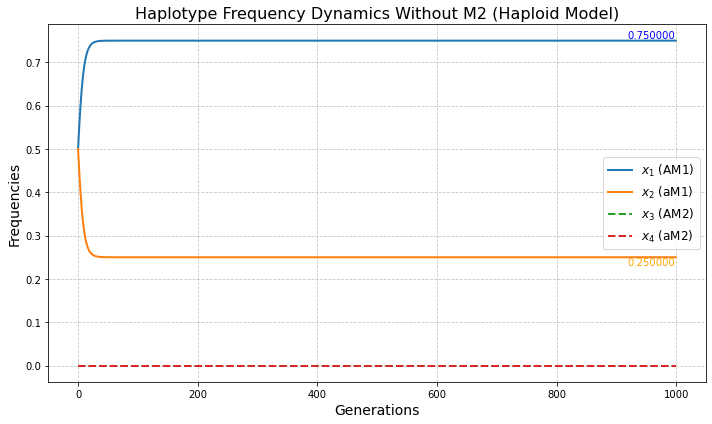

In [159]:
# Just checking it works as predicted
# Define the parameters for the simulation where M2 is not introduced yet
generations = 1000
s = 0.2  # Selection coefficient
u1 = 0.05  # Forward mutation rate for M1
u2 = 0.0  # Forward mutation rate for M2 (not introduced yet)
v1 = 0.0  # Back mutation rate for M1
v2 = 0.0  # Back mutation rate for M2
x1_init = 0.5  # Initial frequency of AM1
x2_init = 0.5  # Initial frequency of aM1
x3_init = 0.0  # Initial frequency of AM2 (not introduced)
x4_init = 0.0  # Initial frequency of aM2 (not introduced)
sigma_2 = 0.0  # No stochasticity in u2

# Simulate the model
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=generations,
    s=s,
    u1=u1,
    u2=u2,
    v1=v1,
    v2=v2,
    x1_init=x1_init,
    x2_init=x2_init,
    x3_init=x3_init,
    x4_init=x4_init,
    sigma_2=sigma_2
)
print(x1[-1], x2[-1], x3[-1], x4[-1])

# Plot the frequencies over generations
plt.figure(figsize=(10, 6))
plt.plot(np.arange(generations), x1, label=r'$x_1$ (AM1)', linewidth=2)
plt.plot(np.arange(generations), x2, label=r'$x_2$ (aM1)', linewidth=2)
plt.plot(np.arange(generations), x3, label=r'$x_3$ (AM2)', linewidth=2, linestyle='--')
plt.plot(np.arange(generations), x4, label=r'$x_4$ (aM2)', linewidth=2, linestyle='--')

# Add labels for the convergent values with more decimal places
plt.text(len(x1) - 1, x1[-1], f'{x1[-1]:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(x1) - 1, x2[-1], f'{x2[-1]:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')

# Adding labels and legend
plt.xlabel('Generations', fontsize=14)
plt.ylabel('Frequencies', fontsize=14)
plt.title('Haplotype Frequency Dynamics Without M2 (Haploid Model)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


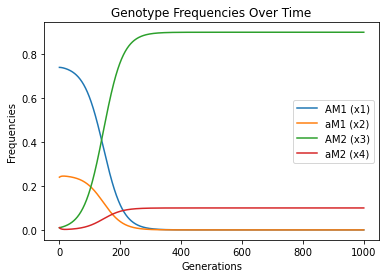

In [160]:
# Deterministic
t= 0.01
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=1000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t
)

# Plot results
plt.plot(x1, label="AM1 (x1)")
plt.plot(x2, label="aM1 (x2)")
plt.plot(x3, label="AM2 (x3)")
plt.plot(x4, label="aM2 (x4)")
plt.xlabel("Generations")
plt.ylabel("Frequencies")
plt.title("Genotype Frequencies Over Time")
plt.legend()
plt.show()

In [161]:
def plot_grouped_frequencies(x1, x2, x3, x4):
    """
    Plot the grouped frequencies for M1 (AM1 + aM1) and M2 (AM2 + aM2) based on the original haplotype frequencies.

    Parameters:
    x1, x2, x3, x4 : numpy arrays - Frequencies of AM1, aM1, AM2, and aM2 over generations.
    """
    # Calculate grouped frequencies
    M1 = x1 + x2  # M1 = AM1 + aM1
    M2 = x3 + x4  # M2 = AM2 + aM2

    # Plot grouped results
    plt.plot(M1, label="M1 (AM1 + aM1)")
    plt.plot(M2, label="M2 (AM2 + aM2)")
    plt.xlabel("Generations")
    plt.ylabel("Frequencies")
    plt.title("Grouped Genotype Frequencies Over Time")
    plt.legend()
    plt.show()

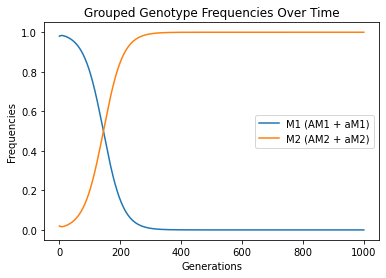

In [162]:
# Deterministic
plot_grouped_frequencies(x1, x2, x3, x4)

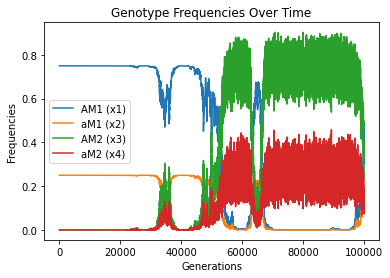

In [163]:
# Stochastic 
t=0.0001
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=100000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t,
    sigma_2 = 0.0515
)
 # Plot results
plt.plot(x1, label="AM1 (x1)")
plt.plot(x2, label="aM1 (x2)")
plt.plot(x3, label="AM2 (x3)")
plt.plot(x4, label="aM2 (x4)")
plt.xlabel("Generations")
plt.ylabel("Frequencies")
plt.title("Genotype Frequencies Over Time")
plt.legend()
plt.show()

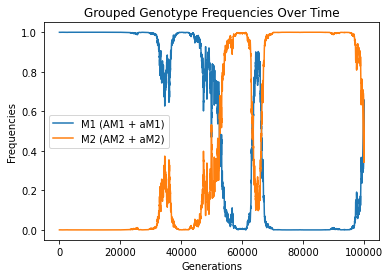

In [164]:
plot_grouped_frequencies(x1, x2, x3, x4)

In [165]:
def plot_final_frequencies_with_sigma(
    sigma_values, generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init
):
    """
    Run haploid_mutation_2m for n steps with a range of sigma_2 values
    and plot final frequencies of M1 and M2.

    Parameters:
    sigma_values : numpy array - Range of sigma_2 values to test
    generations : int - Number of generations to simulate
    s : float - Selection coefficient
    u1, u2 : float - Forward mutation rates
    v1, v2 : float - Back mutation rates
    x1_init, x2_init, x3_init, x4_init : float - Initial frequencies of genotypes AM1, aM1, AM2, aM2

    Returns:
    None (plots the results directly).
    """
    final_M1 = []
    final_M2 = []

    for sigma_2 in sigma_values:
        # Run haploid_mutation_2m for the given sigma_2
        x1, x2, x3, x4 = haploid_mutation_2m(
            generations=generations,
            s=s,
            u1=u1,
            u2=u2,
            v1=v1,
            v2=v2,
            x1_init=x1_init,
            x2_init=x2_init,
            x3_init=x3_init,
            x4_init=x4_init,
            sigma_2=sigma_2,
        )

        # Compute final grouped frequencies
        M1_final = x1[-1] + x2[-1]
        M2_final = x3[-1] + x4[-1]

        final_M1.append(M1_final)
        final_M2.append(M2_final)

    # Plot results
    plt.plot(sigma_values, final_M1, label="M1 (AM1 + aM1)")
    plt.plot(sigma_values, final_M2, label="M2 (AM2 + aM2)")
    plt.xlabel(r"$\sigma_2$")
    plt.ylabel("Frequencies after 100000 Steps")
    plt.title("Final Frequencies vs. $\sigma_2$")
    plt.legend()
    plt.show()



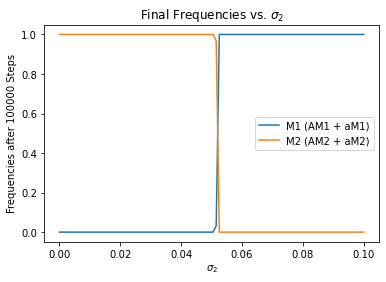

In [166]:
sigma_values = np.linspace(0, 0.1, 100)
plot_final_frequencies_with_sigma(
    sigma_values=sigma_values,
    generations=100000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t
)

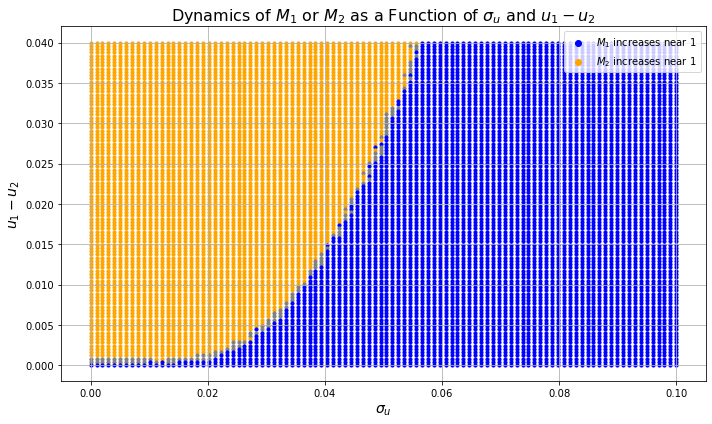

In [4]:
# Parameters
t = 0.001
generations = 10000
u1 = 0.05
u2_values = np.linspace(0.01, 0.05, 100)
sigma_u_values = np.linspace(0, 0.1, 100)
x1_init, x2_init, x3_init, x4_init = 0.76 - t, 0.24 - t, t, t
s, v1, v2, dot_size = 0.2, 0.0, 0.0, 10

# Plot setup
plt.figure(figsize=(10, 6))

for u2 in u2_values:
    for sigma_2 in sigma_u_values:
        x1, x2, x3, x4 = haploid_mutation_2m(generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init, sigma_2)
        M1_final, M2_final = x1[-1] + x2[-1], x3[-1] + x4[-1]
        
        color = 'blue' if M1_final > 0.95 else 'orange' if M2_final > 0.95 else 'gray'
        plt.scatter(sigma_2, u1 - u2, color=color, s=dot_size)

plt.xlabel(r'$\sigma_u$', fontsize=14)
plt.ylabel(r'$u_1 - u_2$', fontsize=14)
plt.title('Dynamics of $M_1$ or $M_2$ as a Function of $\sigma_u$ and $u_1 - u_2$', fontsize=16)
plt.scatter([], [], color='blue', label=r'$M_1$ increases near 1')
plt.scatter([], [], color='orange', label=r'$M_2$ increases near 1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Diploid

In [11]:
def simulate_stochastic_mutation(sigma_u, initial_frequencies, timesteps=1000, u1=0.05, u2=0.02, s=0.2, v1=0.0, seed=None):
    """
    Simulates the evolution of haplotype frequencies under stochastic mutation rates.

    Parameters:
    - sigma_u (float): Standard deviation of the mutation rate for M2, affecting stochasticity.
    - initial_frequencies (list or array): Initial frequencies [x1, x2, x3, x4] of the haplotypes.
                                          Must sum to 1.
    - timesteps (int): Number of generations to simulate.
    - u1 (float): Baseline mutation rate from A to a for M1 haplotypes.
    - u2 (float): Initial baseline mutation rate from A to a for M2 haplotypes.
    - s (float): Selection coefficient. Higher values imply stronger selection against heterozygotes.
    - v1 (float): Reverse mutation rate from a to A (default is 0, no reverse mutation).
    - seed (int or None): Random seed for reproducibility.

    Returns:
    - numpy.ndarray: Final haplotype frequencies [x1, x2, x3, x4] after simulation.
    """

    # Validate input frequencies
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")

    # Set random seed for reproducibility
    rng = np.random.default_rng(seed)

    # Unpack initial frequencies
    x1, x2, x3, x4 = map(float, initial_frequencies)
    frequencies = np.zeros((timesteps, 4))

    for t in range(timesteps):
        frequencies[t] = [x1, x2, x3, x4]
        # Stochastic mutation rate for M2, ensuring it stays within [0, 1]
        while True:
            u2_stochastic = u2 + rng.normal(0, sigma_u)
            if 0 <= u2_stochastic <= 1:
                break

        # # Sample stochastic u2 from a log-normal distribution
        # sigma = np.sqrt(np.log(1 + (sigma_2 / u2)**2))
        # mu = np.log(u2) - 0.5 * sigma**2
        # u2_stochastic = np.random.lognormal(mean=mu, sigma=sigma)
            
        # Calculate mean fitness
        w_bar = (
            x1**2
            + x3**2
            + (1 - 2 * s) * (x2**2 + x4**2)
            + 2 * (1 - s) * (x1 * x2 + x1 * x4 + x2 * x3 + x3 * x4)
            + 2 * x1 * x3
            + 2 * (1 - 2 * s) * x2 * x4
        )

        # Update frequencies after selection
        x1_prime = (x1**2 + x1 * x3 + (1 - s) * (x1 * x2 + x1 * x4)) / w_bar
        x2_prime = ((1 - s) * (x1 * x2 + x2 * x3) + (1 - 2 * s) * (x2**2 + x2 * x4)) / w_bar
        x3_prime = (x3**2 + x1 * x3 + (1 - s) * (x2 * x3 + x3 * x4)) / w_bar
        x4_prime = ((1 - s) * (x1 * x4 + x3 * x4) + (1 - 2 * s) * (x2 * x4 + x4**2)) / w_bar

        # Update frequencies after mutation, ensuring they remain within [0, 1]
        x1 = x1_prime * (1 - u1) + x2_prime * v1
        x2 = x2_prime * (1 - v1) + x1_prime * u1
        x3 = x3_prime * (1 - u2_stochastic) + x4_prime * v1
        x4 = x4_prime * (1 - v1) + x3_prime * u2_stochastic

        # Normalize frequencies to ensure they sum to 1
        total = x1 + x2 + x3 + x4
        x1, x2, x3, x4 = x1 / total, x2 / total, x3 / total, x4 / total
        

    # Round the final frequencies for better numerical stability
    return np.round(frequencies, 6)


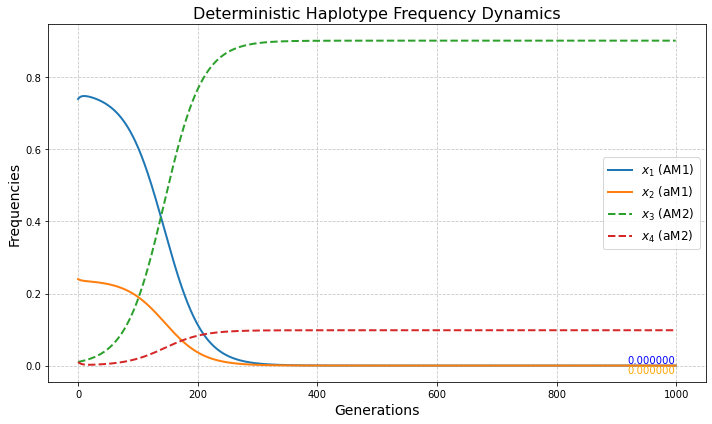

In [13]:
# Setting up initial conditions where M2 is not introduced yet
# This implies that initial frequencies of haplotypes related to M2 (x3, x4) should be 0.
t=0.01
initial_frequencies_no_M2 = [0.75-t, 0.25-t, t, t]  # Only M1-related haplotypes
timesteps = 1000 #1000
sigma_u = 0.0  # No stochasticity as M2 is absent

# Run simulation
frequencies_no_M2 = simulate_stochastic_mutation(
    sigma_u=sigma_u,
    initial_frequencies=initial_frequencies_no_M2,
    timesteps=timesteps,
    u1=0.05,  # Mutation rate for M1
    u2=0.02,   # Mutation rate for M2 set to 0 (M2 not introduced yet)
    s=0.2,    # Selection coefficient
    v1=0.0,   # No reverse mutation
    seed=58   # For reproducibility
)

# Extract final frequencies
final_frequencies_no_M2 = frequencies_no_M2[-1]

# Plotting the convergence dynamics for frequencies when M2 is not introduced
plt.figure(figsize=(10, 6))

# Plot trajectories of haplotype frequencies over time
time_steps = np.arange(timesteps)
plt.plot(time_steps, frequencies_no_M2[:, 0], label=r'$x_1$ (AM1)', linewidth=2)
plt.plot(time_steps, frequencies_no_M2[:, 1], label=r'$x_2$ (aM1)', linewidth=2)
plt.plot(time_steps, frequencies_no_M2[:, 2], label=r'$x_3$ (AM2)', linewidth=2, linestyle='--')
plt.plot(time_steps, frequencies_no_M2[:, 3], label=r'$x_4$ (aM2)', linewidth=2, linestyle='--')

plt.text(len(frequencies_no_M2) - 1, frequencies_no_M2[-1][0], f'{frequencies_no_M2[-1][0]:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(frequencies_no_M2) - 1, frequencies_no_M2[-1][1], f'{frequencies_no_M2[-1][1]:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')
# Adding labels and legend
plt.xlabel('Generations', fontsize=14)
plt.ylabel('Frequencies', fontsize=14)
plt.title('Deterministic Haplotype Frequency Dynamics', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()



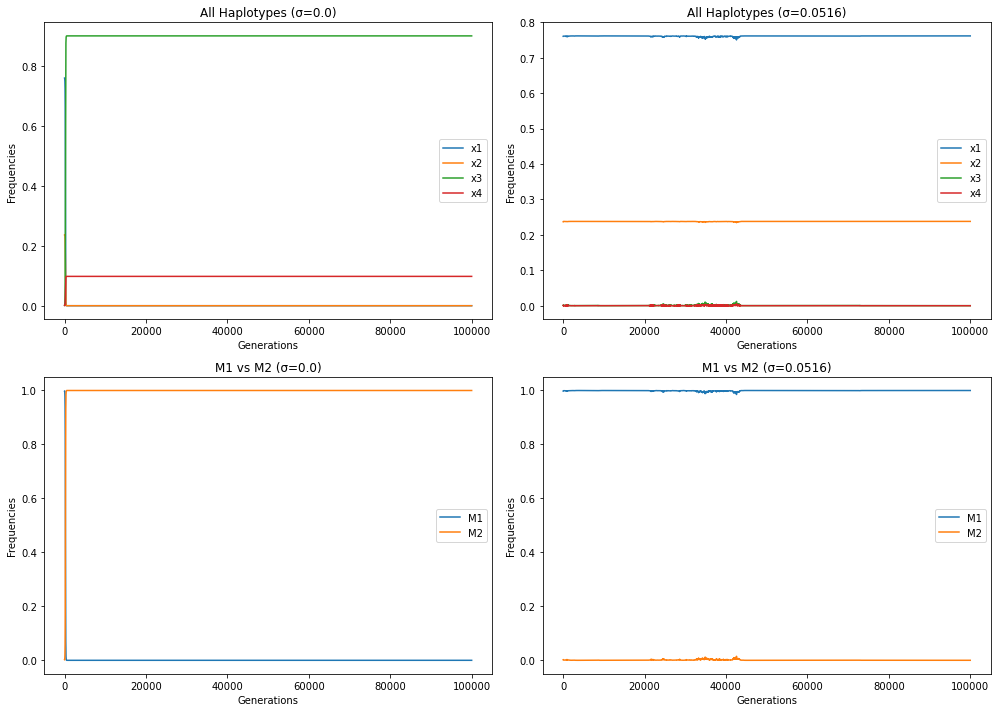

In [13]:
# Simulation parameters
t=0.001
initial_frequencies = [0.761905-t, 0.238095-t, t, t]
timesteps = 100000

# Simulations
frequencies_sigma_0 = simulate_stochastic_mutation(0.0, initial_frequencies, timesteps)
frequencies_sigma_01 = simulate_stochastic_mutation(0.0517, initial_frequencies, timesteps)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot all haplotypes
for i, label in enumerate(["x1", "x2", "x3", "x4"]):
    axes[0, 0].plot(frequencies_sigma_0[:, i], label=label)
    axes[0, 1].plot(frequencies_sigma_01[:, i], label=label)

# Label plots
axes[0, 0].set_title("All Haplotypes (σ=0.0)")
axes[0, 1].set_title("All Haplotypes (σ=0.0516)")
for ax in axes[0]:
    ax.set_xlabel("Generations")
    ax.set_ylabel("Frequencies")
    ax.legend()

# Plot M1 and M2
m1_sigma_0 = frequencies_sigma_0[:, 0] + frequencies_sigma_0[:, 1]
m2_sigma_0 = frequencies_sigma_0[:, 2] + frequencies_sigma_0[:, 3]
m1_sigma_01 = frequencies_sigma_01[:, 0] + frequencies_sigma_01[:, 1]
m2_sigma_01 = frequencies_sigma_01[:, 2] + frequencies_sigma_01[:, 3]

axes[1, 0].plot(m1_sigma_0, label="M1")
axes[1, 0].plot(m2_sigma_0, label="M2")
axes[1, 1].plot(m1_sigma_01, label="M1")
axes[1, 1].plot(m2_sigma_01, label="M2")

# Label plots
axes[1, 0].set_title("M1 vs M2 (σ=0.0)")
axes[1, 1].set_title("M1 vs M2 (σ=0.0516)")
for ax in axes[1]:
    ax.set_xlabel("Generations")
    ax.set_ylabel("Frequencies")
    ax.legend()

plt.tight_layout()
plt.show()

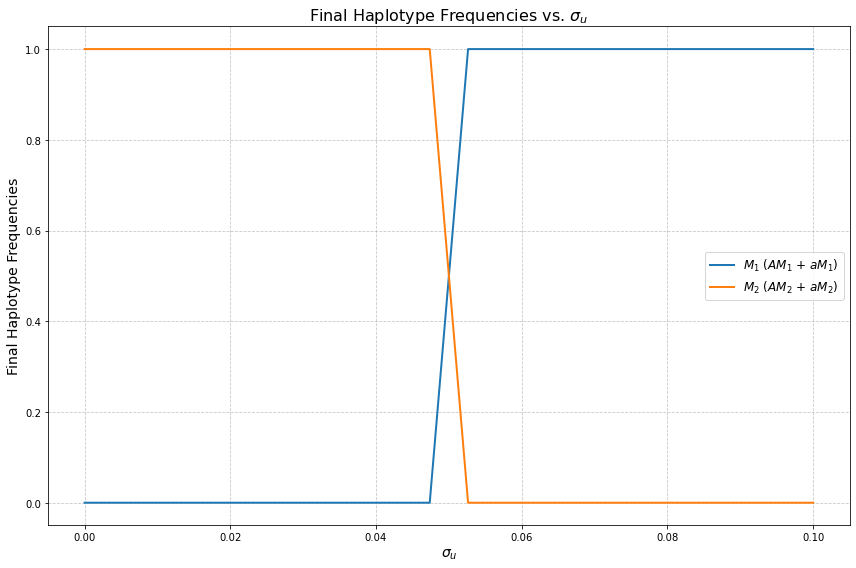

In [14]:
def plot_final_frequencies(
    sigma_u_values,
    initial_frequencies,
    timesteps=100000,
    u1=0.05,
    u2=0.02,
    s=0.2,
    v1=0.0,
    seed=98
):
    """
    Plots the final haplotype frequencies as a function of sigma_u.

    Parameters:
    - sigma_u_values (array-like): Array of sigma_u values to simulate.
                                    Represents the standard deviation of the stochastic mutation rate.
    - initial_frequencies (list or array): Initial haplotype frequencies [x1, x2, x3, x4].
                                            Must sum to 1.
    - timesteps (int): Number of generations to simulate.
    - u1 (float): Baseline mutation rate from A to a for M1 haplotypes.
    - u2 (float): Baseline mutation rate from A to a for M2 haplotypes.
    - s (float): Selection coefficient. Higher values imply stronger selection against heterozygotes.
    - v1 (float): Reverse mutation rate from a to A for M1 and M2 haplotypes.
    - seed (int or None): Random seed for reproducibility.

    Returns:
    None. Displays a plot of final frequencies of M1 and M2 haplotypes as a function of sigma_u.
    """

    # Validate inputs
    if not isinstance(sigma_u_values, (list, np.ndarray)):
        raise TypeError("sigma_u_values must be an array-like object (list or numpy array).")
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")
    
    # Initialize array to store final frequencies
    final_frequencies = np.zeros((len(sigma_u_values), 4))

    # Simulate for each value of sigma_u
    for i, sigma_u in enumerate(sigma_u_values):
        # Extract only the final frequencies after simulation
        final_frequencies[i] = simulate_stochastic_mutation(
            sigma_u,
            initial_frequencies,
            timesteps=timesteps,
            u1=u1,
            u2=u2,
            s=s,
            v1=v1,
            seed=seed
        )[-1]

    # Group results: M1 = AM1 + aM1, M2 = AM2 + aM2
    M1_final = final_frequencies[:, 0] + final_frequencies[:, 1]  # AM1 + aM1
    M2_final = final_frequencies[:, 2] + final_frequencies[:, 3]  # AM2 + aM2

    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.plot(
        sigma_u_values,
        M1_final,
        label=r'$M_1$ ($AM_1$ + $aM_1$)',
        linewidth=2
    )
    plt.plot(
        sigma_u_values,
        M2_final,
        label=r'$M_2$ ($AM_2$ + $aM_2$)',
        linewidth=2
    )
    plt.xlabel(r'$\sigma_u$', fontsize=14)  # LaTeX formatting for sigma_u
    plt.ylabel('Final Haplotype Frequencies', fontsize=14)
    plt.title(r'Final Haplotype Frequencies vs. $\sigma_u$', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Test the function with the corrected implementation
t=0.001
sigma_u_values = np.linspace(0, 0.1, 20)
initial_frequencies = [0.761905-t, 0.238095-t, t, t]
plot_final_frequencies(sigma_u_values, initial_frequencies)


/var/folders/bd/8y0v0_fn5nb59gjxm0ydc3vh0000gn/T/ipykernel_40244/3816414071.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/elisaheinrichmora/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


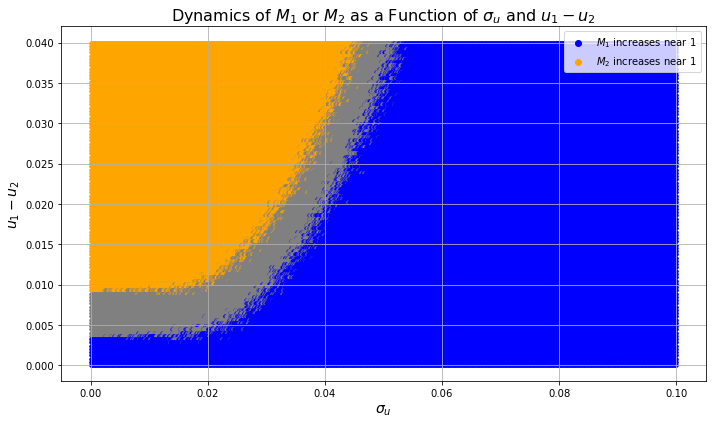

In [171]:
t=0.001
generations = 1000
u1 = 0.05  # Fixed mutation rate for M1
u2_values = np.linspace(0.01, 0.05, 100)  # Range of u2 mutation rates for M2
sigma_u_values = np.linspace(0, 0.1, 1000)  # Range of stochasticity for u2
x1_init, x2_init, x3_init, x4_init = 0.76-t, 0.24-t, t, t  # Initial frequencies
s = 0.2  # Selection coefficient
v1 = 0.0  # No back mutation for M1
v2 = 0.0  # No back mutation for M2
dot_size = 10  # Dot size for scatter plot

# Set up the plot
plt.figure(figsize=(10, 6))

# Iterate over combinations of u2 and sigma_2
for u2 in u2_values:
    for sigma_2 in sigma_u_values:
        # Simulate the haploid model
        x1, x2, x3, x4 = haploid_mutation_2m(
            generations=generations,
            s=s,
            u1=u1,
            u2=u2,
            v1=v1,
            v2=v2,
            x1_init=x1_init,
            x2_init=x2_init,
            x3_init=x3_init,
            x4_init=x4_init,
            sigma_2=sigma_2
        )

        # Group M1 and M2 final frequencies
        M1_final = x1[-1] + x2[-1]  # AM1 + aM1
        M2_final = x3[-1] + x4[-1]  # AM2 + aM2

        # Determine color based on near-fixation
        if M1_final > 0.95:  # M1 wins
            color = 'blue'
        elif M2_final > 0.95:  # M2 wins
            color = 'orange'
        else:  # No near-fixation
            color = 'gray'

        # Plot the point, with x-axis as sigma_2 and y-axis as u1 - u2
        plt.scatter(sigma_2, u1 - u2, color=color, s=dot_size)

# Label the axes and title
plt.xlabel(r'$\sigma_u$', fontsize=14)
plt.ylabel(r'$u_1 - u_2$', fontsize=14)
plt.title('Dynamics of $M_1$ or $M_2$ as a Function of $\sigma_u$ and $u_1 - u_2$', fontsize=16)

# Add a legend
plt.scatter([], [], color='blue', label=r'$M_1$ increases near 1')
plt.scatter([], [], color='orange', label=r'$M_2$ increases near 1')
plt.legend()

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


## Different Distributions

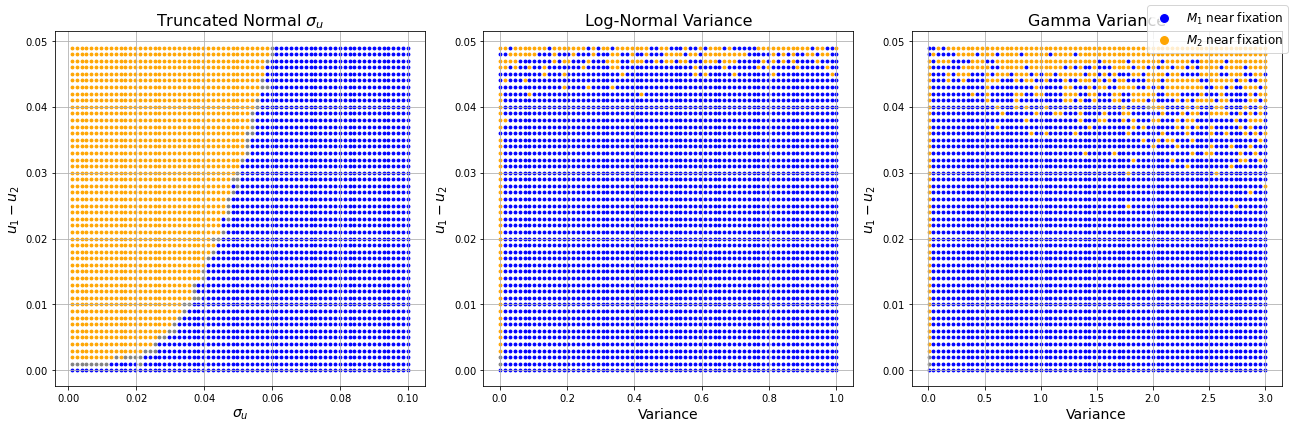

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, lognorm, gamma

# Function to simulate stochastic mutation with different stochasticity models
def simulate_stochastic_mutation(sigma_u, variance, u2_mean, initial_frequencies, timesteps=1000, u1=0.05, s=0.2, v1=0.0, distribution="truncated_normal", seed=None):
    """
    Simulates the evolution of haplotype frequencies under different stochastic mutation rate models.
    """
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")

    rng = np.random.default_rng(seed)

    # Unpack initial frequencies
    x1, x2, x3, x4 = map(float, initial_frequencies)
    frequencies = np.zeros((timesteps, 4))

    for t in range(timesteps):
        frequencies[t] = [x1, x2, x3, x4]

        # Stochastic mutation rate for M2
        while True:
            if distribution == "truncated_normal":
                a, b = (0 - u2_mean) / sigma_u, (1 - u2_mean) / sigma_u
                # u2_stochastic = rng.normal(u2_mean, sigma_u)
                # u2_stochastic = np.clip(u2_stochastic, 0, 1)
                u2_stochastic = truncnorm.rvs(a, b, loc=u2_mean, scale=sigma_u, random_state=rng)


            elif distribution == "log_normal":
                sigma = np.sqrt(np.log(1 + variance / u2_mean**2))
                mu = np.log(u2_mean) - 0.5 * sigma**2
                u2_stochastic = rng.lognormal(mean=mu, sigma=sigma)
                u2_stochastic = np.clip(u2_stochastic, 0, 1)

            elif distribution == "gamma":
                shape = u2_mean**2 / variance
                scale = variance / u2_mean
                u2_stochastic = rng.gamma(shape, scale)
                u2_stochastic = np.clip(u2_stochastic, 0, 1)

            if 0 <= u2_stochastic <= 1:
                break

        # Mean fitness
        w_bar = (
            x1**2 + x3**2 + (1 - 2 * s) * (x2**2 + x4**2) +
            2 * (1 - s) * (x1 * x2 + x1 * x4 + x2 * x3 + x3 * x4) +
            2 * x1 * x3 + 2 * (1 - 2 * s) * x2 * x4
        )

        # Selection step
        x1_prime = (x1**2 + x1 * x3 + (1 - s) * (x1 * x2 + x1 * x4)) / w_bar
        x2_prime = ((1 - s) * (x1 * x2 + x2 * x3) + (1 - 2 * s) * (x2**2 + x2 * x4)) / w_bar
        x3_prime = (x3**2 + x1 * x3 + (1 - s) * (x2 * x3 + x3 * x4)) / w_bar
        x4_prime = ((1 - s) * (x1 * x4 + x3 * x4) + (1 - 2 * s) * (x2 * x4 + x4**2)) / w_bar

        # Mutation step
        x1 = x1_prime * (1 - u1) + x2_prime * v1
        x2 = x2_prime * (1 - v1) + x1_prime * u1
        x3 = x3_prime * (1 - u2_stochastic) + x4_prime * v1
        x4 = x4_prime * (1 - v1) + x3_prime * u2_stochastic

        # Normalize frequencies
        total = x1 + x2 + x3 + x4
        x1, x2, x3, x4 = x1 / total, x2 / total, x3 / total, x4 / total

    return np.round(frequencies, 6)

# Parameters for simulation
t = 0.001
generations = 5000
u1 = 0.05
x1_init, x2_init, x3_init, x4_init = 0.76-t, 0.24-t, t, t  # Initial frequencies
s = 0.2  # Selection coefficient
v1 = 0.0  # No back mutation

# Parameter ranges
u2_mean_values = np.linspace(0.001, u1, 50)  # Mean u2 from 0.001 to u1=0.05

sigma_u_values_truncnorm = np.linspace(0.001, 0.1, 70)
variance_lognorm = np.linspace(0.001, 1, 70)
variance_gamma = np.linspace(0.001, 3, 70)

# List of distributions
distributions = ["truncated_normal", "log_normal", "gamma"]
titles = [r"Truncated Normal $\sigma_u$", r"Log-Normal Variance", r"Gamma Variance"]

# Generate plots for each distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, distribution in enumerate(distributions):
    ax = axes[idx]

    for u2_mean in u2_mean_values:
        if distribution == "truncated_normal":
            sigma_u_values = sigma_u_values_truncnorm
            variance_values = [None] * len(sigma_u_values_truncnorm)
        elif distribution == "log_normal":
            sigma_u_values = [u2_mean] * len(variance_lognorm)
            variance_values = variance_lognorm
        elif distribution == "gamma":
            sigma_u_values = [u2_mean] * len(variance_gamma)
            variance_values = variance_gamma

        for sigma_u, variance in zip(sigma_u_values, variance_values):
            # Simulate the model
            freqs = simulate_stochastic_mutation(
                sigma_u=sigma_u,
                variance=variance,
                u2_mean=u2_mean,
                initial_frequencies=[x1_init, x2_init, x3_init, x4_init],
                timesteps=generations,
                u1=u1,
                s=s,
                v1=v1,
                distribution=distribution,
            )

            # Compute final frequencies
            M1_final = freqs[-1, 0] + freqs[-1, 1]  # AM1 + aM1
            M2_final = freqs[-1, 2] + freqs[-1, 3]  # AM2 + aM2

            # Determine color
            if M1_final > 0.95:
                color = "blue"
            elif M2_final > 0.95:
                color = "orange"
            else:
                color = "gray"

            # Scatter plot
            ax.scatter(sigma_u if variance is None else variance, u1 - u2_mean, color=color, s=8)

    # Labels and formatting
    ax.set_xlabel(r"$\sigma_u$" if variance is None else "Variance", fontsize=14)
    ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.grid(True)

# Legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=10, markerfacecolor="blue", label=r"$M_1$ near fixation"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=10, markerfacecolor="orange", label=r"$M_2$ near fixation"),
]
fig.legend(handles=handles, loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()


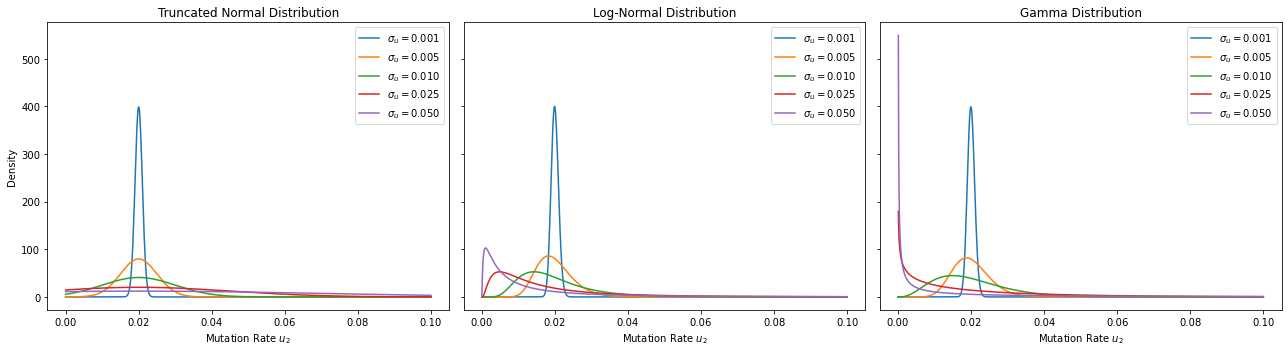

In [8]:
# Set fixed u2 value
u2_fixed = 0.02  

# Define sigma_u values for visualization
sigma_u_values = [0.001, 0.005, 0.01, 0.025, 0.05]  # Example values for different spread

# Define range for plotting distributions
x_values = np.linspace(0, 0.1, 1000)

# Setting up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=True)

# 1. Truncated Normal Distribution
for sigma_u in sigma_u_values:
    a, b = (0 - u2_fixed) / sigma_u, (1 - u2_fixed) / sigma_u  # Truncation bounds
    y_truncnorm = truncnorm.pdf(x_values, a, b, loc=u2_fixed, scale=sigma_u)
    axes[0].plot(x_values, y_truncnorm, label=f"$\sigma_u={sigma_u:.3f}$")

axes[0].set_title("Truncated Normal Distribution")
axes[0].set_xlabel("Mutation Rate $u_2$")
axes[0].set_ylabel("Density")
axes[0].legend()

# 2. Log-Normal Distribution
for sigma_u in sigma_u_values:
    sigma = np.sqrt(np.log(1 + (sigma_u / u2_fixed) ** 2))
    mu = np.log(u2_fixed) - 0.5 * sigma**2
    y_lognorm = lognorm.pdf(x_values, sigma, scale=np.exp(mu))
    axes[1].plot(x_values, y_lognorm, label=f"$\sigma_u={sigma_u:.3f}$")

axes[1].set_title("Log-Normal Distribution")
axes[1].set_xlabel("Mutation Rate $u_2$")
axes[1].legend()

# 3. Gamma Distribution
for sigma_u in sigma_u_values:
    shape = (u2_fixed / sigma_u) ** 2
    scale = sigma_u ** 2 / u2_fixed
    y_gamma = gamma.pdf(x_values, shape, scale=scale)
    axes[2].plot(x_values, y_gamma, label=f"$\sigma_u={sigma_u:.3f}$")

axes[2].set_title("Gamma Distribution")
axes[2].set_xlabel("Mutation Rate $u_2$")
axes[2].legend()

plt.tight_layout()
plt.show()
